<a href="https://colab.research.google.com/github/cwvaldezp/ProyectoFinalSeq2SeqLSTM/blob/main/Traductor_seq2seq_LSTM_CWVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 1 - Carga y preparación del dataset

En esta sección se realiza la carga y exploración del dataset de traducción Inglés–Español.  
El dataset contiene pares de oraciones alineadas que serán utilizadas para entrenar un modelo de traducción automática basado en redes neuronales.

Se realiza una limpieza básica del texto, incluyendo normalización, conversión a minúsculas y eliminación de caracteres innecesarios.  
Posteriormente, el dataset es dividido en tres subconjuntos:

- **Training set**: utilizado para entrenar el modelo.
- **Validation set**: utilizado para ajustar hiperparámetros y aplicar early stopping.
- **Test set**: utilizado únicamente para evaluar el desempeño final del modelo.

Esta separación permite medir la capacidad de generalización del modelo y evitar sobreajuste.

### Instalar dependencias

In [788]:
# Instalar la librería unidecode.
# Sirve para convertir caracteres con tilde o símbolos especiales
# a una versión más simple. Por ejemplo:
# "canción" -> "cancion"
!pip install -q unidecode

### Importar librerías

In [789]:
# Librería para trabajar con carpetas y rutas de archivos
import os

# Librería para expresiones regulares, útil para limpiar texto
import re

# Librería para operaciones matemáticas
import math

# Librería para medir tiempo de ejecución
import time

# Librería para aleatoriedad controlada
import random

# Librería para descomprimir archivos zip
import zipfile

# Librería para descargar archivos desde internet
import urllib.request

# Counter sirve para contar frecuencias de palabras
from collections import Counter

# Librería numérica muy usada para arreglos y operaciones matemáticas
import numpy as np

# Librería para manejo de tablas tipo DataFrame
import pandas as pd

# unidecode transforma texto con acentos a texto plano
from unidecode import unidecode

# Sirve para dividir el dataset en train, validation y test
from sklearn.model_selection import train_test_split

# Librería principal de PyTorch
import torch

# Módulo de redes neuronales de PyTorch
import torch.nn as nn

# Clases para construir datasets y dataloaders
from torch.utils.data import Dataset, DataLoader

### Configuración general

In [790]:
# Definimos una semilla fija para que los resultados sean reproducibles.
# Esto hace que, si vuelves a correr el notebook, obtengas resultados similares.
SEED = 42

# Fija la semilla del módulo random de Python
random.seed(SEED)

# Fija la semilla de NumPy
np.random.seed(SEED)

# Fija la semilla de PyTorch en CPU
torch.manual_seed(SEED)

# Fija la semilla de PyTorch en GPU (si existe)
torch.cuda.manual_seed_all(SEED)

# Detecta si hay GPU disponible.
# Si hay GPU usa "cuda", si no usa "cpu".
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Muestra en pantalla qué dispositivo usará el modelo
print("Device:", device)

# Token especial para indicar inicio de oración
SOS_TOKEN = "<sos>"

# Token especial para indicar final de oración
EOS_TOKEN = "<eos>"

# Token especial para completar secuencias cortas
PAD_TOKEN = "<pad>"

# Token especial para palabras desconocidas
UNK_TOKEN = "<unk>"

Device: cuda


### Crear carpeta y definir ruta del dataset

In [791]:
# DESCARGAR spa.txt DIRECTAMENTE

# Librerías para manejar rutas y hacer descargas HTTP
import os
import requests

# Carpeta donde guardaremos el dataset
DATA_DIR = "/content/data"

# Crea la carpeta si no existe
os.makedirs(DATA_DIR, exist_ok=True)

# URL RAW real del archivo spa.txt
# Ojo: aquí usamos raw.githubusercontent.com, no github.com/blob/...
url = "https://raw.githubusercontent.com/s-hironobu/guide2dl/main/DataSets/keras/spa-eng/spa.txt"

# Ruta local donde se guardará el archivo
txt_path = os.path.join(DATA_DIR, "spa.txt")

# Encabezado para simular navegador normal
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Hace la descarga
response = requests.get(url, headers=headers, timeout=60)

# Verifica que el servidor respondió bien
response.raise_for_status()

# Guarda el contenido en disco como texto
with open(txt_path, "wb") as f:
    f.write(response.content)

# Confirma dónde quedó guardado
print("Archivo guardado en:", txt_path)

# Muestra tamaño del archivo
print("Tamaño en bytes:", os.path.getsize(txt_path))

# Lee una pequeña muestra para confirmar que sí es texto
with open(txt_path, "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().strip())

Archivo guardado en: /content/data/spa.txt
Tamaño en bytes: 8042772
Go.	Ve.
Go.	Vete.
Go.	Vaya.
Go.	Váyase.
Hi.	Hola.


### Cargar el dataset

In [792]:
# LEER EL DATASET DESDE spa.txt

# Ruta del archivo ya descargado
data_file = "/content/data/spa.txt"

# Abre el archivo en modo lectura con UTF-8
with open(data_file, "r", encoding="utf-8") as f:

    # Lee todas las líneas, quita espacios sobrantes y separa por salto de línea
    lines = f.read().strip().split("\n")

# Muestra cuántas líneas hay
print("Número total de líneas:", len(lines))

# Muestra las primeras 5 para revisar formato
print("\nPrimeras 5 líneas:")
for i in range(5):
    print(lines[i])

Número total de líneas: 118964

Primeras 5 líneas:
Go.	Ve.
Go.	Vete.
Go.	Vaya.
Go.	Váyase.
Hi.	Hola.


### Diagnóstico del Archivo

In [793]:
# DIAGNÓSTICO DEL ARCHIVO

file_path = "/content/data/spa.txt"

# Lee los primeros bytes del archivo
with open(file_path, "rb") as f:
    head = f.read(200)

print(head[:200])

b'Go.\tVe.\nGo.\tVete.\nGo.\tVaya.\nGo.\tV\xc3\xa1yase.\nHi.\tHola.\nRun!\t\xc2\xa1Corre!\nRun.\tCorred.\nWho?\t\xc2\xbfQui\xc3\xa9n?\nFire!\t\xc2\xa1Fuego!\nFire!\t\xc2\xa1Incendio!\nFire!\t\xc2\xa1Disparad!\nHelp!\t\xc2\xa1Ayuda!\nHelp!\t\xc2\xa1Socorro! \xc2\xa1Auxilio!\nHelp!\t\xc2\xa1Auxil'


### Leer el archivo de texto

In [794]:
# Construye la ruta completa del archivo principal del dataset
# En este dataset normalmente el archivo se llama "spa.txt"
data_file = os.path.join(DATA_DIR, "spa.txt")

# Abre el archivo en modo lectura usando codificación utf-8
with open(data_file, "r", encoding="utf-8") as f:

    # Lee todo el archivo como un solo texto,
    # elimina espacios vacíos al inicio/final
    # y lo divide por saltos de línea
    lines = f.read().strip().split("\n")

# Muestra cuántas líneas tiene el archivo
print("Número total de líneas:", len(lines))

# Muestra las primeras 5 líneas para inspeccionar el formato
print(lines[:5])

Número total de líneas: 118964
['Go.\tVe.', 'Go.\tVete.', 'Go.\tVaya.', 'Go.\tVáyase.', 'Hi.\tHola.']


### Extraer pares inglés-español

In [795]:
# Creamos una lista vacía donde guardaremos los pares (inglés, español)
pairs = []

# Recorremos cada línea del archivo
for line in lines:

    # Cada línea viene separada por tabulaciones:
    # inglés \t español \t metadatos
    parts = line.split("\t")

    # Verificamos que al menos existan dos columnas
    if len(parts) >= 2:

        # Primera columna: frase en inglés
        en = parts[0].strip()

        # Segunda columna: frase en español
        es = parts[1].strip()

        # Guardamos la tupla (inglés, español)
        pairs.append((en, es))

# Muestra cuántos pares se extrajeron
print("Total de pares:", len(pairs))

# Muestra los primeros 10 ejemplos
for i in range(10):
    print(pairs[i])

Total de pares: 118964
('Go.', 'Ve.')
('Go.', 'Vete.')
('Go.', 'Vaya.')
('Go.', 'Váyase.')
('Hi.', 'Hola.')
('Run!', '¡Corre!')
('Run.', 'Corred.')
('Who?', '¿Quién?')
('Fire!', '¡Fuego!')
('Fire!', '¡Incendio!')


### Función para limpiar texto

In [796]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?¿¡,])", r" \1 ", text)
    text = re.sub(r"[^a-záéíóúüñA-ZÁÉÍÓÚÜÑ.!?¿¡,']+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### Aplicar limpieza a todos los pares

In [797]:
# Creamos una nueva lista con los pares ya normalizados
pairs_clean = []

# Recorremos cada par original
for en, es in pairs:

    # Limpiamos la frase en inglés
    en_clean = normalize_text(en)

    # Limpiamos la frase en español
    es_clean = normalize_text(es)

    # Guardamos el nuevo par limpio
    pairs_clean.append((en_clean, es_clean))

# Muestra algunos ejemplos después de la limpieza
print("Ejemplos limpios:")
for i in range(10):
    print(pairs_clean[i])

Ejemplos limpios:
('go .', 've .')
('go .', 'vete .')
('go .', 'vaya .')
('go .', 'váyase .')
('hi .', 'hola .')
('run !', '¡ corre !')
('run .', 'corred .')
('who ?', '¿ quién ?')
('fire !', '¡ fuego !')
('fire !', '¡ incendio !')


### Filtrar frases largas y limitar tamaño del dataset

In [798]:
# Longitud máxima permitida por oración en número de palabras
# Esto ayuda a que el entrenamiento sea más rápido y más estable
MAX_SENTENCE_LENGTH = 20

# Número máximo de ejemplos que vamos a usar por ahora
# Para comenzar en Colab es mejor usar un subconjunto
# MAX_NUM_SAMPLES = 30000
MAX_NUM_SAMPLES = len(pairs)

# Lista donde guardaremos los pares filtrados
filtered_pairs = []

# Recorremos todos los pares limpios
for en, es in pairs_clean:

    # Contamos cuántas palabras tiene la oración en inglés
    en_len = len(en.split())

    # Contamos cuántas palabras tiene la oración en español
    es_len = len(es.split())

    # Solo guardamos el par si ambas oraciones son cortas
    if en_len <= MAX_SENTENCE_LENGTH and es_len <= MAX_SENTENCE_LENGTH:
        filtered_pairs.append((en, es))

# Tomamos solo los primeros MAX_NUM_SAMPLES ejemplos
filtered_pairs = filtered_pairs[:MAX_NUM_SAMPLES]

# Muestra cuántos pares quedaron
print("Número de pares filtrados:", len(filtered_pairs))

# Muestra algunos ejemplos
for i in range(10):
    print(filtered_pairs[i])

Número de pares filtrados: 118650
('go .', 've .')
('go .', 'vete .')
('go .', 'vaya .')
('go .', 'váyase .')
('hi .', 'hola .')
('run !', '¡ corre !')
('run .', 'corred .')
('who ?', '¿ quién ?')
('fire !', '¡ fuego !')
('fire !', '¡ incendio !')


### Dividir en train, validation y test

In [799]:
# Primero sacamos el 70% train
train_pairs, temp_pairs = train_test_split(
    filtered_pairs,
    test_size=0.3,
    random_state=SEED
)

# Ahora del 30% restante:
# queremos 20% validation y 10% test

# Entonces validation debe ser 20/30 = 0.6666
test_pairs, val_pairs = train_test_split(
    temp_pairs,
    test_size=2/3,
    random_state=SEED
)

print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 83055
Validation: 23730
Test: 11865


### Ver algunos ejemplos de cada split

In [800]:
# Muestra 5 ejemplos de entrenamiento
print("=== Ejemplos de TRAIN ===")
for i in range(5):
    print(train_pairs[i])

# Muestra 5 ejemplos de validación
print("\n=== Ejemplos de VALIDATION ===")
for i in range(5):
    print(val_pairs[i])

# Muestra 5 ejemplos de prueba
print("\n=== Ejemplos de TEST ===")
for i in range(5):
    print(test_pairs[i])

=== Ejemplos de TRAIN ===
('she is everything to him .', 'ella lo es todo para él .')
('tom was in boston last month .', 'tom estuvo en boston el mes pasado .')
('you can go anywhere you like .', 'podéis ir donde queráis .')
('we have little opportunity to use english .', 'apenas tenemos ocasión de usar el inglés .')
("he's not a good person .", 'no es una buena persona .')

=== Ejemplos de VALIDATION ===
("i don't know how you can believe such nonsense .", 'no sé cómo podés creer esas tonterías .')
('we can help .', 'podemos ayudar .')
('tom has been , and still is , a constant source of worry to his parents .', 'tom ha sido y sigue siendo una fuente constante de preocupación para sus padres .')
('as she grew older , she became more beautiful .', 'conforme fue creciendo , ella se volvió más y más bella .')
('does tom have mental problems ?', '¿ tom tiene problemas mentales ?')

=== Ejemplos de TEST ===
('the tall man looked at tom and smiled .', 'el hombre alto miró a tom y sonrió .')

# Parte 2 - Vocabulario y DataLoaders

En esta etapa se construye el vocabulario tanto para el idioma fuente (inglés) como para el idioma objetivo (español).  
Cada palabra es mapeada a un índice entero para permitir su procesamiento por el modelo neuronal.

Se incluyen tokens especiales:

- `<pad>`: utilizado para completar secuencias cortas
- `<sos>`: indica el inicio de la secuencia
- `<eos>`: indica el fin de la secuencia
- `<unk>`: representa palabras desconocidas

Las oraciones son convertidas a secuencias de índices y luego se aplica **padding** para garantizar que todas tengan la misma longitud dentro de cada batch.

Finalmente, se implementan objetos `Dataset` y `DataLoader` de PyTorch para permitir entrenamiento eficiente en batches.

### Construir vocabulario

In [801]:
# Creamos contadores de palabras para inglés y español
en_counter = Counter()
es_counter = Counter()

# Recorremos solo el dataset de entrenamiento
# (MUY IMPORTANTE: vocabulario se construye SOLO con train)
for en, es in train_pairs:

    # Cuenta cuántas veces aparece cada palabra y divide la
    # frase en palabras .split()
    en_counter.update(en.split())
    es_counter.update(es.split())

# Mostramos tamaño del vocabulario
print("Vocabulario inglés:", len(en_counter))
print("Vocabulario español:", len(es_counter))

Vocabulario inglés: 11686
Vocabulario español: 21986


### Crear diccionarios

In [802]:
# CREAR word2idx y idx2word

# Tokens especiales
special_tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

# Diccionario inglés palabra → índice
en_word2idx = {token: idx for idx, token in enumerate(special_tokens)}

# Agregar palabras del vocabulario
for word, _ in en_counter.most_common():
    if word not in en_word2idx:
        en_word2idx[word] = len(en_word2idx)

# Diccionario español palabra → índice
es_word2idx = {token: idx for idx, token in enumerate(special_tokens)}

for word, _ in es_counter.most_common():
    if word not in es_word2idx:
        es_word2idx[word] = len(es_word2idx)

# Diccionarios inversos
en_idx2word = {idx: word for word, idx in en_word2idx.items()}
es_idx2word = {idx: word for word, idx in es_word2idx.items()}

print("Tamaño vocab inglés:", len(en_word2idx))
print("Tamaño vocab español:", len(es_word2idx))

Tamaño vocab inglés: 11690
Tamaño vocab español: 21990


### Función para convertir frase → índices

In [803]:
# TEXT → INDICES

def sentence_to_indices(sentence, word2idx, add_sos=True, add_eos=True):
    tokens = sentence.split()
    indices = []

    if add_sos:
        indices.append(word2idx[SOS_TOKEN])

    for token in tokens:
        indices.append(word2idx.get(token, word2idx[UNK_TOKEN]))

    if add_eos:
        indices.append(word2idx[EOS_TOKEN])

    return indices

### Probar conversión

In [804]:
# Probamos con un ejemplo
example = train_pairs[0]

print("Frase original EN:", example[0])
print("Índices EN:", sentence_to_indices(example[0], en_word2idx))

print("Frase original ES:", example[1])
print("Índices ES:", sentence_to_indices(example[1], es_word2idx))

Frase original EN: she is everything to him .
Índices EN: [1, 26, 12, 196, 7, 44, 4, 2]
Frase original ES: ella lo es todo para él .
Índices ES: [1, 31, 22, 15, 59, 33, 19, 4, 2]


### Dataset para seq2seq

In [805]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_word2idx, tgt_word2idx):
        self.pairs = pairs
        self.src_word2idx = src_word2idx
        self.tgt_word2idx = tgt_word2idx

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence, tgt_sentence = self.pairs[idx]

        # Encoder input: <sos> ... <eos>
        src_indices = sentence_to_indices(
            src_sentence,
            self.src_word2idx,
            add_sos=True,
            add_eos=True
        )

        # Decoder input: <sos> ...
        tgt_input_indices = sentence_to_indices(
            tgt_sentence,
            self.tgt_word2idx,
            add_sos=True,
            add_eos=False
        )

        # Decoder target: ... <eos>
        tgt_output_indices = sentence_to_indices(
            tgt_sentence,
            self.tgt_word2idx,
            add_sos=False,
            add_eos=True
        )

        return {
            "src": torch.tensor(src_indices, dtype=torch.long),
            "tgt_input": torch.tensor(tgt_input_indices, dtype=torch.long),
            "tgt_output": torch.tensor(tgt_output_indices, dtype=torch.long)
        }

### Collate function con padding dinámico

In [806]:
def collate_fn(batch):
    src_list = [item["src"] for item in batch]
    tgt_input_list = [item["tgt_input"] for item in batch]
    tgt_output_list = [item["tgt_output"] for item in batch]

    src_lengths = torch.tensor([len(seq) for seq in src_list], dtype=torch.long)

    src_padded = nn.utils.rnn.pad_sequence(
        src_list,
        batch_first=True,
        padding_value=en_word2idx[PAD_TOKEN]
    )

    tgt_input_padded = nn.utils.rnn.pad_sequence(
        tgt_input_list,
        batch_first=True,
        padding_value=es_word2idx[PAD_TOKEN]
    )

    tgt_output_padded = nn.utils.rnn.pad_sequence(
        tgt_output_list,
        batch_first=True,
        padding_value=es_word2idx[PAD_TOKEN]
    )

    return src_padded, src_lengths, tgt_input_padded, tgt_output_padded

### DataLoaders

In [807]:
BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, en_word2idx, es_word2idx)
val_dataset = TranslationDataset(val_pairs, en_word2idx, es_word2idx)
test_dataset = TranslationDataset(test_pairs, en_word2idx, es_word2idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1298
Validation batches: 371
Test batches: 186


### Probar un batch

#### Esto es clave antes de crear el modelo.

In [808]:
src_batch, src_lengths, tgt_input_batch, tgt_output_batch = next(iter(train_loader))

print("src_batch shape:", src_batch.shape)
print("src_lengths shape:", src_lengths.shape)
print("tgt_input_batch shape:", tgt_input_batch.shape)
print("tgt_output_batch shape:", tgt_output_batch.shape)

print("\nPrimer ejemplo src:", src_batch[0])
print("Primer ejemplo tgt_input:", tgt_input_batch[0])
print("Primer ejemplo tgt_output:", tgt_output_batch[0])

src_batch shape: torch.Size([64, 16])
src_lengths shape: torch.Size([64])
tgt_input_batch shape: torch.Size([64, 14])
tgt_output_batch shape: torch.Size([64, 14])

Primer ejemplo src: tensor([  1,  32,  82, 577, 252, 703,   4,   2,   0,   0,   0,   0,   0,   0,
          0,   0])
Primer ejemplo tgt_input: tensor([   1,  146,  737,  187, 2138,    4,    0,    0,    0,    0,    0,    0,
           0,    0])
Primer ejemplo tgt_output: tensor([ 146,  737,  187, 2138,    4,    2,    0,    0,    0,    0,    0,    0,
           0,    0])


## Parte 3 — Arquitectura Seq2Seq basada en LSTM

El modelo de traducción automática implementado sigue el paradigma **Sequence-to-Sequence (Seq2Seq)**, donde una oración en inglés es transformada en su equivalente en español mediante una arquitectura Encoder–Decoder basada en redes neuronales recurrentes del tipo **Long Short-Term Memory (LSTM)**.

El flujo general del modelo puede describirse como:

**Inglés → Encoder LSTM → Representación contextual (hidden & cell state) → Decoder LSTM → Español**

### Encoder

El encoder procesa la secuencia de palabras en inglés y genera una representación vectorial contextual que resume la información semántica completa de la oración.  
Esta representación está compuesta por el **hidden state** y el **cell state**, los cuales capturan dependencias temporales y contexto de largo alcance.

### Decoder

El decoder utiliza esta representación contextual para generar la traducción en español de forma **autoregresiva**, es decir, prediciendo una palabra a la vez hasta producir el token de fin de secuencia (`<eos>`).

Durante el entrenamiento se emplea la técnica de **teacher forcing**, que consiste en alimentar al decoder con la palabra real esperada en lugar de la palabra predicha por el modelo, lo cual ayuda a estabilizar el aprendizaje y mejorar la velocidad de convergencia.

El modelo incluye **capas de embedding aprendibles**, posibles **múltiples capas LSTM**, y **dropout** como mecanismo de regularización para reducir el riesgo de sobreajuste.

### Encoder

In [809]:
# ENCODER LSTM

class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers=1, dropout=0.2, pad_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        # src: (batch_size, src_len)
        # src_lengths: (batch_size)

        embedded = self.dropout(self.embedding(src))
        # embedded: (batch_size, src_len, embed_dim)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_outputs, (hidden, cell) = self.lstm(packed_embedded)

        # hidden: (num_layers, batch_size, hidden_dim)
        # cell:   (num_layers, batch_size, hidden_dim)

        return hidden, cell

### Decoder

In [810]:
# DECODER LSTM

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers=1, dropout=0.2, pad_idx=0):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell):
        # input_token: (batch_size)
        # hidden: (num_layers, batch_size, hidden_dim)
        # cell:   (num_layers, batch_size, hidden_dim)

        input_token = input_token.unsqueeze(1)
        # (batch_size, 1)

        embedded = self.dropout(self.embedding(input_token))
        # (batch_size, 1, embed_dim)

        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: (batch_size, 1, hidden_dim)

        prediction = self.fc_out(output.squeeze(1))
        # (batch_size, output_dim)

        return prediction, hidden, cell

### Modelo Seq2Seq completo

In [811]:
# SEQ2SEQ LSTM

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt_input, teacher_forcing_ratio=0.3):
        # src: (batch_size, src_len)
        # src_lengths: (batch_size)
        # tgt_input: (batch_size, tgt_len)

        batch_size = src.shape[0]
        tgt_len = tgt_input.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size, device=self.device)

        hidden, cell = self.encoder(src, src_lengths)

        input_token = tgt_input[:, 0]   # <sos>

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)

            outputs[:, t, :] = output

            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio

            input_token = tgt_input[:, t] if teacher_force else top1

        return outputs

### Definir hiperparámetros del modelo

In [812]:
# HIPERPARÁMETROS

INPUT_DIM = len(en_word2idx)
OUTPUT_DIM = len(es_word2idx)

EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.2

ENC_PAD_IDX = en_word2idx[PAD_TOKEN]
DEC_PAD_IDX = es_word2idx[PAD_TOKEN]

print("INPUT_DIM:", INPUT_DIM)
print("OUTPUT_DIM:", OUTPUT_DIM)

INPUT_DIM: 11690
OUTPUT_DIM: 21990


### Instanciar encoder, decoder y modelo completo

In [813]:
encoder = Encoder(
    input_dim=INPUT_DIM,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=ENC_PAD_IDX
)

decoder = Decoder(
    output_dim=OUTPUT_DIM,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=DEC_PAD_IDX
)

model = Seq2Seq(encoder, decoder, device).to(device)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(11690, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(21990, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc_out): Linear(in_features=256, out_features=21990, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)


### Probar una pasada con un batch real

In [814]:
# Tomamos un batch del dataloader de entrenamiento
src_batch, src_lengths, tgt_input_batch, tgt_output_batch = next(iter(train_loader))

# Movemos al device
src_batch = src_batch.to(device)
src_lengths = src_lengths.to(device)
tgt_input_batch = tgt_input_batch.to(device)
tgt_output_batch = tgt_output_batch.to(device)

print("src_batch shape:", src_batch.shape)
print("src_lengths shape:", src_lengths.shape)
print("tgt_input_batch shape:", tgt_input_batch.shape)
print("tgt_output_batch shape:", tgt_output_batch.shape)

# Forward
outputs = model(src_batch, src_lengths, tgt_input_batch)

print("outputs shape:", outputs.shape)

src_batch shape: torch.Size([64, 18])
src_lengths shape: torch.Size([64])
tgt_input_batch shape: torch.Size([64, 18])
tgt_output_batch shape: torch.Size([64, 18])
outputs shape: torch.Size([64, 18, 21990])


### Contar parámetros del modelo

In [815]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"El modelo tiene {count_parameters(model):,} parámetros entrenables.")

El modelo tiene 10,752,998 parámetros entrenables.


## Parte 4 - Entrenamiento, validación y checkpoints

El modelo es entrenado utilizando el optimizador **Adam**, debido a su buen desempeño en problemas de secuencias y aprendizaje profundo.

La función de pérdida utilizada es **Cross Entropy Loss**, ignorando el token `<pad>` para evitar que el modelo aprenda de posiciones artificiales introducidas por el padding.

Se aplica **gradient clipping** para prevenir explosión de gradientes, fenómeno común en redes recurrentes profundas.

Durante el entrenamiento se monitorea la pérdida en el conjunto de validación.  
Se implementa una estrategia de **early stopping** para detener el entrenamiento cuando el modelo deja de mejorar, evitando sobreajuste.

Adicionalmente, se guardan **checkpoints por época**, permitiendo comparar diferentes estados del modelo y realizar fine-tuning posterior.

### Definir optimizador y función de pérdida

In [816]:
# OPTIMIZADOR Y FUNCIÓN DE PÉRDIDA

import torch.optim as optim

# Adam es un optimizador adaptativo muy usado en NLP
# Ajusta el learning rate automáticamente por parámetro
optimizer = optim.Adam(model.parameters(), lr=0.001)

# CrossEntropyLoss compara logits vs target real
# ignore_index evita penalizar el padding
criterion = nn.CrossEntropyLoss(ignore_index=es_word2idx[PAD_TOKEN])

### Función auxiliar para medir tiempo

In [817]:
# FUNCIÓN PARA MEDIR TIEMPO

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    mins = int(elapsed_time // 60)
    secs = int(elapsed_time % 60)
    return mins, secs

### Función de entrenamiento

In [818]:
# FUNCIÓN DE ENTRENAMIENTO

def train_fn(model, dataloader, optimizer, criterion, clip, device):

    model.train()   # activa dropout

    epoch_loss = 0

    for src, src_lengths, tgt_input, tgt_output in dataloader:

        src = src.to(device)
        src_lengths = src_lengths.to(device)
        tgt_input = tgt_input.to(device)
        tgt_output = tgt_output.to(device)

        optimizer.zero_grad()

        # Forward con teacher forcing
        output = model(src, src_lengths, tgt_input, teacher_forcing_ratio=0.3)

        output_dim = output.shape[-1]

        # ignoramos <sos>
        output = output[:, 1:, :].reshape(-1, output_dim)
        tgt_output = tgt_output[:, 1:].reshape(-1)

        loss = criterion(output, tgt_output)

        loss.backward()

        # evita exploding gradients en RNN
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

### Función de validación

In [819]:
# FUNCIÓN DE VALIDACIÓN

def evaluate_fn(model, dataloader, criterion, device):

    model.eval()   # desactiva dropout

    epoch_loss = 0

    with torch.no_grad():

        for src, src_lengths, tgt_input, tgt_output in dataloader:

            src = src.to(device)
            src_lengths = src_lengths.to(device)
            tgt_input = tgt_input.to(device)
            tgt_output = tgt_output.to(device)

            # sin teacher forcing
            output = model(src, src_lengths, tgt_input, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]

            output = output[:, 1:, :].reshape(-1, output_dim)
            tgt_output = tgt_output[:, 1:].reshape(-1)

            loss = criterion(output, tgt_output)

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

### Configurar entrenamiento

In [820]:
# CONFIGURACIÓN GENERAL

N_EPOCHS = 50
CLIP = 1.0

best_valid_loss = float("inf")

train_losses = []
val_losses = []

# Early stopping
PATIENCE = 10
epochs_without_improvement = 0

# Carpeta checkpoints
CHECKPOINT_DIR = "/content/checkpoints_seq2seq_lstm_v10"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

### Entrenar el modelo por épocas
#### Loop principal de entrenamiento

In [821]:
# ==============================
# LOOP DE ENTRENAMIENTO
# ==============================

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP, device)
    valid_loss = evaluate_fn(model, val_loader, criterion, device)

    end_time = time.time()

    mins, secs = epoch_time(start_time, end_time)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(f"Epoch {epoch+1} | {mins}m {secs}s")
    print(f"Train Loss {train_loss:.3f}")
    print(f"Val Loss {valid_loss:.3f}")

    # guardar checkpoint
    ckpt_path = os.path.join(
        CHECKPOINT_DIR,
        f"checkpoint_epoch{epoch+1:02}_valloss{valid_loss:.4f}.pt"
    )

    torch.save({
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": valid_loss,
        "input_dim": INPUT_DIM,
        "output_dim": OUTPUT_DIM
    }, ckpt_path)

    # guardar mejor modelo
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch+1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": valid_loss
        }, os.path.join(CHECKPOINT_DIR,"best_model.pt"))

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping")
        break

Epoch 1 | 1m 15s
Train Loss 5.141
Val Loss 4.595
Epoch 2 | 1m 14s
Train Loss 4.200
Val Loss 4.051
Epoch 3 | 1m 12s
Train Loss 3.659
Val Loss 3.726
Epoch 4 | 1m 15s
Train Loss 3.272
Val Loss 3.532
Epoch 5 | 1m 15s
Train Loss 2.975
Val Loss 3.404
Epoch 6 | 1m 15s
Train Loss 2.746
Val Loss 3.321
Epoch 7 | 1m 18s
Train Loss 2.560
Val Loss 3.266
Epoch 8 | 1m 14s
Train Loss 2.404
Val Loss 3.230
Epoch 9 | 1m 17s
Train Loss 2.280
Val Loss 3.221
Epoch 10 | 1m 15s
Train Loss 2.177
Val Loss 3.202
Epoch 11 | 1m 14s
Train Loss 2.090
Val Loss 3.203
Epoch 12 | 1m 15s
Train Loss 2.017
Val Loss 3.196
Epoch 13 | 1m 14s
Train Loss 1.951
Val Loss 3.198
Epoch 14 | 1m 15s
Train Loss 1.898
Val Loss 3.197
Epoch 15 | 1m 15s
Train Loss 1.852
Val Loss 3.197
Epoch 16 | 1m 14s
Train Loss 1.801
Val Loss 3.204
Epoch 17 | 1m 15s
Train Loss 1.763
Val Loss 3.211
Epoch 18 | 1m 10s
Train Loss 1.728
Val Loss 3.223
Epoch 19 | 1m 13s
Train Loss 1.690
Val Loss 3.233
Epoch 20 | 1m 16s
Train Loss 1.661
Val Loss 3.225
Epoch 21 

### Ver checkpoints

In [822]:
checkpoint_files = sorted(
    [f for f in os.listdir(CHECKPOINT_DIR)
     if f.endswith(".pt") and f != "best_model.pt"]
)

### Comparar checkpoints

In [823]:
def evaluate_checkpoint(path, model, dataloader, criterion, device):

    ckpt = torch.load(path, map_location=device)
    print(ckpt["input_dim"], ckpt["output_dim"])
    print(INPUT_DIM, OUTPUT_DIM)
    model.load_state_dict(ckpt["model_state_dict"])

    loss = evaluate_fn(model, dataloader, criterion, device)

    return {
        "checkpoint": os.path.basename(path),
        "epoch": ckpt["epoch"],
        "saved_val_loss": ckpt["val_loss"],
        "evaluated_loss": loss
    }

### Tabla de resultados

In [824]:
results = []

for f in checkpoint_files:
    p = os.path.join(CHECKPOINT_DIR, f)
    results.append(
        evaluate_checkpoint(p, model, val_loader, criterion, device)
    )

results_df = pd.DataFrame(results).sort_values("evaluated_loss")
results_df

11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990
11690 21990


,checkpoint,epoch,saved_val_loss,evaluated_loss
11,checkpoint_epoch12_valloss3.1956.pt,12,3.195594,3.195594
13,checkpoint_epoch14_valloss3.1967.pt,14,3.196655,3.196655
14,checkpoint_epoch15_valloss3.1970.pt,15,3.196953,3.196953
12,checkpoint_epoch13_valloss3.1984.pt,13,3.198363,3.198363
9,checkpoint_epoch10_valloss3.2025.pt,10,3.202497,3.202497
10,checkpoint_epoch11_valloss3.2033.pt,11,3.203293,3.203293
15,checkpoint_epoch16_valloss3.2040.pt,16,3.203981,3.203981
16,checkpoint_epoch17_valloss3.2109.pt,17,3.210899,3.210899
8,checkpoint_epoch09_valloss3.2207.pt,9,3.220690,3.220690
17,checkpoint_epoch18_valloss3.2233.pt,18,3.223328,3.223328


### Gráfica evolución checkpoints

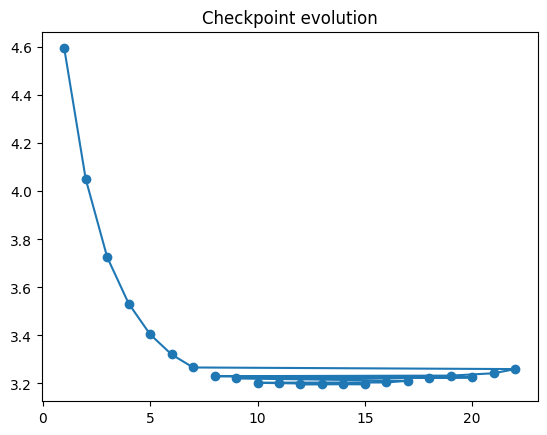

In [825]:
import matplotlib.pyplot as plt

plt.plot(results_df["epoch"], results_df["saved_val_loss"], marker="o")
plt.title("Checkpoint evolution")
plt.show()

### Fine-Tuning
#### Crear carpeta exclusiva de fine-tuning:

In [826]:
#CHECKPOINT_DIR_FT = "/content/checkpoints_seq2seq/finetune"
CHECKPOINT_DIR_FT = os.path.join(CHECKPOINT_DIR, "finetune")

os.makedirs(CHECKPOINT_DIR_FT, exist_ok=True)

print("Fine-tuning checkpoints en:", CHECKPOINT_DIR_FT)

Fine-tuning checkpoints en: /content/checkpoints_seq2seq_lstm_v10/finetune


#### Cargar modelo base

In [827]:
base_ckpt = torch.load(
    os.path.join(CHECKPOINT_DIR,"best_model.pt"),
    map_location=device
)

model.load_state_dict(base_ckpt["model_state_dict"])

print("Modelo base cargado.")
print("Epoch base:", base_ckpt["epoch"])
print("Val loss base:", base_ckpt["val_loss"])

Modelo base cargado.
Epoch base: 12
Val loss base: 3.195594342892382


#### Optimizer nuevo

In [828]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

#### Variables FT

In [829]:
FINE_TUNE_EPOCHS = 10

fine_tune_train_losses = []
fine_tune_val_losses = []

best_ft_valid_loss = float("inf")
ft_epochs_without_improvement = 0
FT_PATIENCE = 3

#### Loop FT

In [830]:
for epoch in range(FINE_TUNE_EPOCHS):

    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP, device)
    val_loss = evaluate_fn(model, val_loader, criterion, device)

    fine_tune_train_losses.append(train_loss)
    fine_tune_val_losses.append(val_loss)

    if val_loss < best_ft_valid_loss:
        best_ft_valid_loss = val_loss
        ft_epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "val_loss": val_loss
        }, os.path.join(CHECKPOINT_DIR_FT,"best_finetuned_model.pt"))

    else:
        ft_epochs_without_improvement += 1

    if ft_epochs_without_improvement >= FT_PATIENCE:
        break

#### Evaluar mejor modelo BASE

In [831]:
ckpt = torch.load(os.path.join(CHECKPOINT_DIR,"best_model.pt"))
model.load_state_dict(ckpt["model_state_dict"])

test_loss = evaluate_fn(model, test_loader, criterion, device)
print(test_loss)

3.2492085836266957


#### Evaluar mejor modelo Fine-Tuned

In [832]:
ckpt = torch.load(os.path.join(CHECKPOINT_DIR_FT,"best_finetuned_model.pt"))
model.load_state_dict(ckpt["model_state_dict"])

test_loss_ft = evaluate_fn(model, test_loader, criterion, device)
print(test_loss_ft)

3.1941715555806316


### Gráficas finales

#### Base

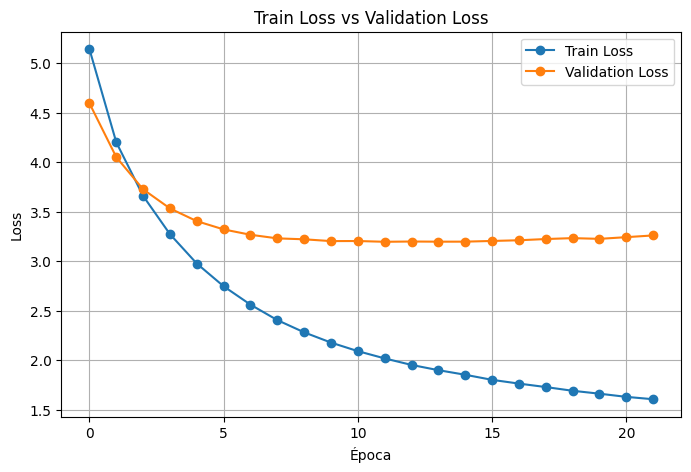

In [833]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Train Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#### Fine-tuning

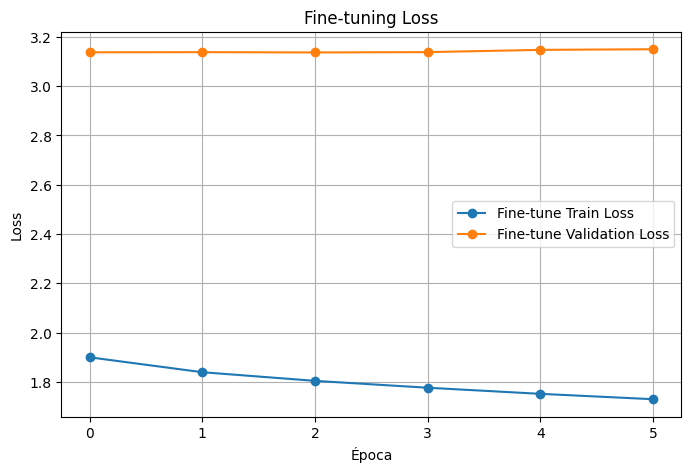

In [834]:
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_train_losses, marker="o", label="Fine-tune Train Loss")
plt.plot(fine_tune_val_losses, marker="o", label="Fine-tune Validation Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Fine-tuning Loss")
plt.legend()
plt.grid(True)
plt.show()

#### Comparación global

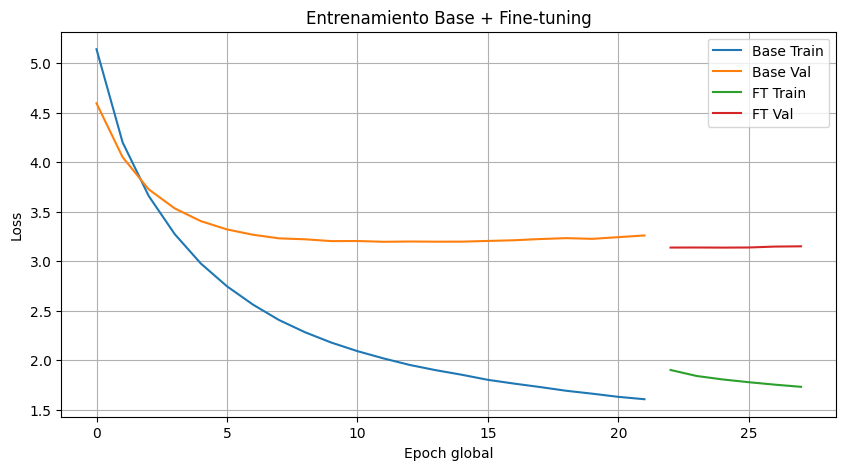

In [835]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Base Train")
plt.plot(val_losses, label="Base Val")
offset = len(train_losses)
plt.plot( range(offset, offset + len(fine_tune_train_losses)), fine_tune_train_losses, label="FT Train" )
plt.plot( range(offset, offset + len(fine_tune_val_losses)), fine_tune_val_losses, label="FT Val" )
plt.xlabel("Epoch global")
plt.ylabel("Loss")
plt.title("Entrenamiento Base + Fine-tuning")
plt.legend()
plt.grid(True)
plt.show()

## Parte 5 - Inferencia y evaluación del modelo

En esta sección se evalúa el desempeño del modelo entrenado.

Se implementa una función de traducción autoregresiva que genera la oración en español token por token hasta producir el token de fin `<eos>` o alcanzar una longitud máxima.

El modelo es evaluado tanto de forma cualitativa como cuantitativa:

- Comparación de traducciones generadas frente a las reales.
- Evaluación del desempeño en diferentes checkpoints.
- Visualización de la evolución de la pérdida.
- Cálculo del **BLEU Score**, métrica estándar para evaluar calidad de traducción automática.

Finalmente, se incluye una interfaz interactiva que permite introducir frases manualmente para observar el comportamiento del modelo en tiempo real.

### Función para convertir índices → texto

In [836]:
# FUNCIÓN PARA CONVERTIR ÍNDICES A TEXTO

def indices_to_sentence(indices, idx2word):
    """
    Convierte una lista de índices a una oración legible.

    Parámetros:
    - indices: lista de enteros
    - idx2word: diccionario índice -> palabra

    Retorna:
    - oración en texto
    """

    words = []

    for idx in indices:
        word = idx2word.get(int(idx), UNK_TOKEN)

        # Si encontramos <eos>, terminamos
        if word == EOS_TOKEN:
            break

        # Ignoramos tokens especiales que no deben mostrarse
        if word not in [SOS_TOKEN, PAD_TOKEN]:
            words.append(word)

    return " ".join(words)

### Función para Preparar frase de entrada

In [837]:
# FUNCIÓN PARA PREPARAR UNA FRASE DE ENTRADA

def prepare_input_sentence(sentence):
    """
    Limpia una frase en inglés, la convierte a índices
    y la transforma en tensor para inferencia.

    Parámetros:
    - sentence: frase en inglés (string)

    Retorna:
    - src_tensor: tensor de shape (1, seq_len)
    - src_length: tensor con la longitud real de la secuencia
    """

    # Limpiamos la frase igual que en entrenamiento
    sentence = normalize_text(sentence)

    # Convertimos la frase a índices
    indices = sentence_to_indices(
        sentence,
        en_word2idx,
        add_sos=True,
        add_eos=True
    )

    # Convertimos a tensor y agregamos dimensión batch
    src_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    # Guardamos la longitud real
    src_length = torch.tensor([len(indices)], dtype=torch.long).to(device)

    return src_tensor, src_length

### Función de traducción

In [838]:
# FUNCIÓN DE TRADUCCIÓN

def translate_sentence(model, sentence_en, max_len=20, device=device):
    model.eval()
    with torch.no_grad():
        # 1) Normalizar igual que en el preprocesado
        sentence_norm = normalize_text(sentence_en)
        src_indices = sentence_to_indices(
            sentence_norm,
            en_word2idx,
            add_sos=True,
            add_eos=True
        )
        src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)
        src_lengths = torch.tensor([len(src_indices)], dtype=torch.long).to(device)

        # 2) Pasar por el encoder
        hidden, cell = model.encoder(src_tensor, src_lengths)

        # 3) Decoding autoregresivo
        sos_idx = es_word2idx[SOS_TOKEN]
        eos_idx = es_word2idx[EOS_TOKEN]

        input_token = torch.tensor([sos_idx], dtype=torch.long).to(device)
        generated_indices = []

        for _ in range(max_len):
            output, hidden, cell = model.decoder(input_token, hidden, cell)
            top1 = output.argmax(1)
            idx = top1.item()
            if idx == eos_idx:
                break
            generated_indices.append(idx)
            input_token = top1

        # 4) Convertir índices a palabras
        words = [es_idx2word[i] for i in generated_indices if i in es_idx2word]
        words = [w for w in words if w not in {SOS_TOKEN, EOS_TOKEN, PAD_TOKEN}]
        return " ".join(words)


### Probar traducciones manuales

In [839]:
# PROBAR TRADUCCIONES MANUALES

sentences = [
    "i am tired",
    "she is my friend",
    "we love apples",
    "this is a beautiful house"
]

for s in sentences:
    print("EN:", s)
    print("ES:", translate_sentence(model, s))
    print("-"*50)

EN: i am tired
ES: cansado cansada
--------------------------------------------------
EN: she is my friend
ES: es amigo amigo
--------------------------------------------------
EN: we love apples
ES: encantan manzanas
--------------------------------------------------
EN: this is a beautiful house
ES: es una casa grande
--------------------------------------------------


### Evaluar algunos ejemplos del test set

    Aquí veremos:
    frase original en inglés EN
    referencia real en español REAL
    traducción generada por el modelo PRED

In [840]:
# EVALUAR ALGUNOS EJEMPLOS DEL TEST SET

def evaluate_test_examples(model, test_pairs, num_examples=5, max_len=20):
    """
    Muestra ejemplos del test set con:
    - frase original en inglés
    - traducción real en español
    - traducción generada por el modelo
    """

    for i in range(num_examples):
        en_sentence, es_sentence = test_pairs[i]

        pred_sentence = translate_sentence(
            model,
            en_sentence,
            max_len=max_len
        )

        print(f"Ejemplo {i+1}")
        print("EN:   ", en_sentence)
        print("REAL: ", es_sentence)
        print("PRED: ", pred_sentence)
        print("-" * 80)

In [841]:
evaluate_test_examples(
    model=model,
    test_pairs=test_pairs,
    num_examples=10,
    max_len=20
)

Ejemplo 1
EN:    the tall man looked at tom and smiled .
REAL:  el hombre alto miró a tom y sonrió .
PRED:  hombre alto alto a tom y sonrió sonrió
--------------------------------------------------------------------------------
Ejemplo 2
EN:    i've been told that i'm a good kisser .
REAL:  me han dicho que soy bueno besando .
PRED:  dijeron que que que un un . .
--------------------------------------------------------------------------------
Ejemplo 3
EN:    step aside .
REAL:  hazte a un lado .
PRED:  fue paso .
--------------------------------------------------------------------------------
Ejemplo 4
EN:    may i see your driver's license , sir ?
REAL:  ¿ puedo ver su licencia de conducir , señor ?
PRED:  puedo ver su carnet de conducir de ? ?
--------------------------------------------------------------------------------
Ejemplo 5
EN:    tom is one of my closest friends .
REAL:  tom es uno de mis amigos más íntimos .
PRED:  es uno de mis amigos mis amigos
-------------------------

### Comparar traducciones entre checkpoints

In [842]:
def translate_with_checkpoint(checkpoint_path, sentence, max_len=20):
    """
    Carga un checkpoint específico y traduce una frase.

    Parámetros:
    - checkpoint_path: ruta del checkpoint .pt
    - sentence: frase en inglés
    - max_len: longitud máxima de la traducción

    Retorna:
    - traducción generada en español
    """

    # Cargamos el checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Restauramos los pesos del modelo
    model.load_state_dict(checkpoint["model_state_dict"])

    # Traducimos usando la función principal
    translation = translate_sentence(model, sentence, max_len=max_len)

    return translation

#### Ejemplo con 3 checkpoints:

In [843]:
# EJEMPLO CON 3 CHECKPOINTS

# Frase de ejemplo
example_sentence = "i am very happy"

# Tomamos 3 checkpoints para comparar
selected_checkpoints = checkpoint_files[:3]

print("Frase original:", example_sentence)
print()

for ckpt_file in selected_checkpoints:
    ckpt_path = os.path.join(CHECKPOINT_DIR, ckpt_file)

    translation = translate_with_checkpoint(
        ckpt_path,
        example_sentence,
        max_len=20
    )

    print("Checkpoint:", ckpt_file)
    print("Traducción:", translation)
    print("-" * 60)

Frase original: i am very happy

Checkpoint: checkpoint_epoch01_valloss4.5949.pt
Traducción: muy muy .
------------------------------------------------------------
Checkpoint: checkpoint_epoch02_valloss4.0507.pt
Traducción: muy feliz
------------------------------------------------------------
Checkpoint: checkpoint_epoch03_valloss3.7256.pt
Traducción: feliz feliz
------------------------------------------------------------


#### Comparar varias frases:

In [844]:
# COMPARAR VARIAS FRASES

sample_sentences = [
    "i am very happy",
    "she is my friend",
    "we love apples"
]

selected_checkpoints = checkpoint_files[:3]

for sentence in sample_sentences:
    print("=" * 80)
    print("Frase original:", sentence)
    print()

    for ckpt_file in selected_checkpoints:
        ckpt_path = os.path.join(CHECKPOINT_DIR, ckpt_file)

        translation = translate_with_checkpoint(
            ckpt_path,
            sentence,
            max_len=20
        )

        print("Checkpoint:", ckpt_file)
        print("Traducción:", translation)
        print()

    print("=" * 80)
    print()

Frase original: i am very happy

Checkpoint: checkpoint_epoch01_valloss4.5949.pt
Traducción: muy muy .

Checkpoint: checkpoint_epoch02_valloss4.0507.pt
Traducción: muy feliz

Checkpoint: checkpoint_epoch03_valloss3.7256.pt
Traducción: feliz feliz


Frase original: she is my friend

Checkpoint: checkpoint_epoch01_valloss4.5949.pt
Traducción: es mi mi ?

Checkpoint: checkpoint_epoch02_valloss4.0507.pt
Traducción: es mi mi ?

Checkpoint: checkpoint_epoch03_valloss3.7256.pt
Traducción: es mi amigo


Frase original: we love apples

Checkpoint: checkpoint_epoch01_valloss4.5949.pt
Traducción: están !

Checkpoint: checkpoint_epoch02_valloss4.0507.pt
Traducción: a ?

Checkpoint: checkpoint_epoch03_valloss3.7256.pt
Traducción: estamos ?




### Tabla de checkpoints con epoch, val_loss y test_loss
#### Celda: evaluar checkpoints guardados

In [845]:
# TABLA DE CHECKPOINTS CON EPOCH, VAL_LOSS Y TEST_LOSS

def build_checkpoint_results_table(checkpoint_files, checkpoint_dir, model, test_loader, criterion, device):
    """
    Evalúa todos los checkpoints sobre test
    y construye una tabla resumen.

    Parámetros:
    - checkpoint_files: lista de nombres de checkpoints
    - checkpoint_dir: carpeta donde están los checkpoints
    - model: modelo seq2seq
    - test_loader: dataloader de test
    - criterion: función de pérdida
    - device: cpu o cuda

    Retorna:
    - DataFrame con resultados
    """

    results = []

    for ckpt_file in checkpoint_files:
        ckpt_path = os.path.join(checkpoint_dir, ckpt_file)

        # Cargamos checkpoint
        checkpoint = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])

        # Evaluamos en test
        test_loss = evaluate_fn(model, test_loader, criterion, device)

        # Guardamos resultados
        results.append({
            "checkpoint": ckpt_file,
            "epoch": checkpoint.get("epoch", None),
            "val_loss": checkpoint.get("val_loss", None),
            "test_loss": test_loss
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="test_loss", ascending=True).reset_index(drop=True)

    return results_df

In [846]:
# Construimos la tabla de checkpoints
checkpoint_results_df = build_checkpoint_results_table(
    checkpoint_files=checkpoint_files,
    checkpoint_dir=CHECKPOINT_DIR,
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device
)

checkpoint_results_df

,checkpoint,epoch,val_loss,test_loss
0,checkpoint_epoch12_valloss3.1956.pt,12,3.195594,3.249209
1,checkpoint_epoch14_valloss3.1967.pt,14,3.196655,3.252253
2,checkpoint_epoch11_valloss3.2033.pt,11,3.203293,3.254055
3,checkpoint_epoch10_valloss3.2025.pt,10,3.202497,3.255239
4,checkpoint_epoch15_valloss3.1970.pt,15,3.196953,3.256090
5,checkpoint_epoch13_valloss3.1984.pt,13,3.198363,3.259487
6,checkpoint_epoch16_valloss3.2040.pt,16,3.203981,3.267161
7,checkpoint_epoch17_valloss3.2109.pt,17,3.210899,3.274587
8,checkpoint_epoch09_valloss3.2207.pt,9,3.220690,3.274822
9,checkpoint_epoch08_valloss3.2301.pt,8,3.230105,3.281982


### Gráfica de checkpoints

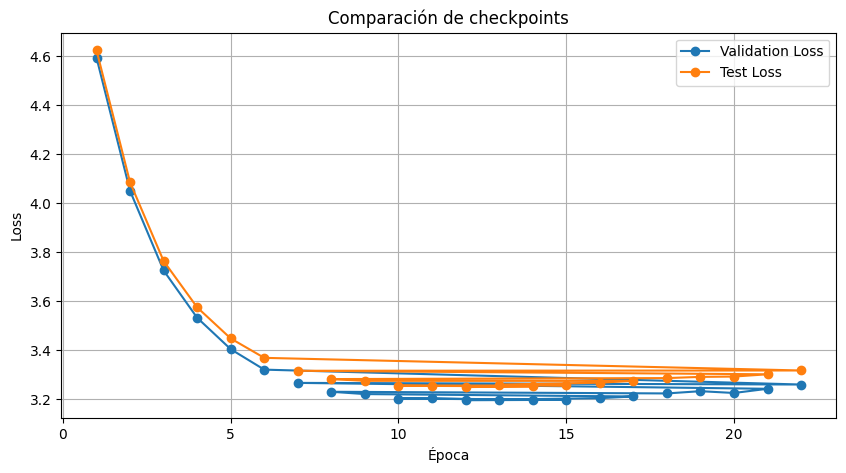

In [847]:
# GRÁFICA DE CHECKPOINTS

plt.figure(figsize=(10, 5))

plt.plot(
    checkpoint_results_df["epoch"],
    checkpoint_results_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.plot(
    checkpoint_results_df["epoch"],
    checkpoint_results_df["test_loss"],
    marker="o",
    label="Test Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Comparación de checkpoints")
plt.legend()
plt.grid(True)
plt.show()

### BLEU Score en Test Set

In [848]:
# Instalamos/importamos NLTK si hace falta
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [849]:
# BLEU SCORE EN TEST SET
def compute_bleu_score(model, test_pairs, max_samples=1000, max_len=20):
    """
    Calcula BLEU Score sobre un subconjunto del test set.

    Parámetros:
    - model: modelo entrenado
    - test_pairs: lista de pares (en, es)
    - max_samples: número máximo de muestras para evaluar
    - max_len: longitud máxima de traducción

    Retorna:
    - bleu_score: valor BLEU
    """

    references = []
    hypotheses = []

    smoothie = SmoothingFunction().method1

    for en_sentence, es_sentence in test_pairs[:max_samples]:
        # Traducción generada
        pred_sentence = translate_sentence(model, en_sentence, max_len=max_len)

        # Referencia esperada
        references.append([es_sentence.split()])

        # Hipótesis del modelo
        hypotheses.append(pred_sentence.split())

    bleu_score = corpus_bleu(
        references,
        hypotheses,
        smoothing_function=smoothie
    )

    return bleu_score

### Calcular BLEU

In [850]:
# Cargamos el mejor modelo base antes de medir BLEU
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

bleu_score = compute_bleu_score(
    model=model,
    test_pairs=test_pairs,
    max_samples=1000,
    max_len=20
)

print(f"BLEU Score en test: {bleu_score:.4f}")

BLEU Score en test: 0.1226


In [851]:
# INTERPRETACIÓN DEL BLEU SCORE

print("Interpretación aproximada del BLEU Score:")
print("- BLEU cercano a 0.00: traducciones muy pobres.")
print("- BLEU entre 0.10 y 0.20: traducciones básicas.")
print("- BLEU entre 0.20 y 0.30: desempeño aceptable para un seq2seq básico.")
print("- BLEU entre 0.30 y 0.50: buen desempeño.")
print("- BLEU mayor a 0.50: desempeño muy sólido.")

Interpretación aproximada del BLEU Score:
- BLEU cercano a 0.00: traducciones muy pobres.
- BLEU entre 0.10 y 0.20: traducciones básicas.
- BLEU entre 0.20 y 0.30: desempeño aceptable para un seq2seq básico.
- BLEU entre 0.30 y 0.50: buen desempeño.
- BLEU mayor a 0.50: desempeño muy sólido.


### Resumen de resultados

In [852]:
print("Resumen final del proyecto")
print(f"Mejor Validation Loss: {best_valid_loss:.4f}")
print(f"Test Loss modelo base: {test_loss:.4f}")
print(f"Test Loss modelo fine-tuned: {test_loss_ft:.4f}")
print(f"BLEU Score: {bleu_score:.4f}")

Resumen final del proyecto
Mejor Validation Loss: 3.1956
Test Loss modelo base: 3.2492
Test Loss modelo fine-tuned: 3.1942
BLEU Score: 0.1226


### Función interactiva

In [853]:
# TRADUCTOR INTERACTIVO

def interactive_translation():
    """
    Permite ingresar frases manualmente
    para que el modelo las traduzca.
    Escribe 'salir' para terminar.
    """

    print("Traductor inglés -> español")
    print("Escribe una frase en inglés. Para terminar escribe: salir")
    print()

    while True:
        sentence = input("Ingresa una frase: ").strip()

        if sentence.lower() == "salir":
            print("Fin de la sesión interactiva.")
            break

        translation = translate_sentence(model, sentence, max_len=20)

        print("Traducción:", translation)
        print()

In [854]:
## interactive_translation()

## Conclusión del experimento

El modelo Seq2Seq basado en LSTM logra aprender correspondencias básicas entre oraciones en inglés y español, mostrando capacidad de generalización moderada en el conjunto de test.

Sin embargo, se observan limitaciones en oraciones largas y estructuras gramaticales complejas.  
Futuras mejoras podrían incluir:

- Mecanismos de **attention**
- Arquitecturas **Transformer**
- Entrenamiento con datasets más grandes
- Subword tokenization (BPE)

Estos enfoques podrían mejorar significativamente la calidad de traducción.